<a href="https://colab.research.google.com/github/iagocava/projeto_ml_estoque_erp.ipynb/blob/main/projeto_ml_estoque_erp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introdução


# Projeto de Machine Learning: Previsão de Reposição de Estoque em Sistema ERP

Este projeto tem como objetivo aplicar técnicas de Machine Learning para prever se determinado item de estoque precisa ou não ser reposto.

O problema será tratado como uma tarefa de classificação binária, em que:

- 1 = o produto precisa de reposição;
- 0 = o produto não precisa de reposição.

A base de dados simula informações típicas de um sistema ERP, como estoque atual, estoque mínimo, consumo médio mensal, prazo de reposição, categoria do produto, fornecedor e valor unitário.

Serão treinados e comparados dois modelos:

- Regressão Logística;
- Random Forest.

# Importacao das bibliotecas

In [ ]:
# Instalação das bibliotecas principais
!pip install pandas numpy matplotlib scikit-learn

In [ ]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt

# Separação dos dados e validação
from sklearn.model_selection import train_test_split, GridSearchCV

# Pré-processamento
from sklearn.preprocessing import StandardScaler

# Modelos de Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Métricas de avaliação
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Criacao e leitura base de dados

In [ ]:
# Criacao da base de dados
# Definindo uma semente para permitir reprodução dos resultados
np.random.seed(42)

# Quantidade de registros da base
n = 1000

# Criação da base simulada
df = pd.DataFrame({
    "produto": [f"Produto_{i}" for i in range(1, n + 1)],
    "categoria": np.random.choice(
        ["Escritorio", "Informatica", "Hospitalar", "Limpeza", "Manutencao"],
        size=n
    ),
    "fornecedor": np.random.choice(
        ["Fornecedor_A", "Fornecedor_B", "Fornecedor_C", "Fornecedor_D"],
        size=n
    ),
    "estoque_atual": np.random.randint(0, 500, size=n),
    "estoque_minimo": np.random.randint(20, 150, size=n),
    "consumo_medio_mensal": np.random.randint(5, 250, size=n),
    "prazo_reposicao_dias": np.random.randint(2, 45, size=n),
    "valor_unitario": np.round(np.random.uniform(5, 1000, size=n), 2)
})

# Cálculo do consumo estimado durante o prazo de reposição
df["consumo_durante_reposicao"] = (
    df["consumo_medio_mensal"] / 30
) * df["prazo_reposicao_dias"]

# Criação da variável-alvo
# Regra: precisa repor quando o estoque atual está abaixo do estoque mínimo
# ou quando o estoque atual não cobre o consumo estimado durante o prazo de reposição
df["precisa_repor"] = (
    (df["estoque_atual"] < df["estoque_minimo"]) |
    (df["estoque_atual"] < df["consumo_durante_reposicao"])
).astype(int)

# Visualizar as primeiras linhas
df.head()

,produto,categoria,fornecedor,estoque_atual,estoque_minimo,consumo_medio_mensal,prazo_reposicao_dias,valor_unitario,consumo_durante_reposicao,precisa_repor
0,Produto_1,Limpeza,Fornecedor_D,374,47,106,38,652.17,134.266667,0
1,Produto_2,Manutencao,Fornecedor_D,427,70,122,40,216.27,162.666667,0
2,Produto_3,Hospitalar,Fornecedor_D,304,24,214,33,126.40,235.400000,0
3,Produto_4,Manutencao,Fornecedor_D,359,24,158,18,702.88,94.800000,0
4,Produto_5,Manutencao,Fornecedor_D,458,113,138,36,117.87,165.600000,0


In [ ]:
# Salvando a base de dados em arquivo CSV
df.to_csv("estoque_erp.csv", index=False)

print("Arquivo estoque_erp.csv criado com sucesso.")

Arquivo estoque_erp.csv criado com sucesso.


In [ ]:
# para baixar o arquivo local para testes
from google.colab import files

files.download("estoque_erp.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# leitura da base de dados
# Leitura do arquivo CSV
df = pd.read_csv("estoque_erp.csv")

# Visualizar as cinco primeiras linhas
df.head()

,produto,categoria,fornecedor,estoque_atual,estoque_minimo,consumo_medio_mensal,prazo_reposicao_dias,valor_unitario,consumo_durante_reposicao,precisa_repor
0,Produto_1,Limpeza,Fornecedor_D,374,47,106,38,652.17,134.266667,0
1,Produto_2,Manutencao,Fornecedor_D,427,70,122,40,216.27,162.666667,0
2,Produto_3,Hospitalar,Fornecedor_D,304,24,214,33,126.40,235.400000,0
3,Produto_4,Manutencao,Fornecedor_D,359,24,158,18,702.88,94.800000,0
4,Produto_5,Manutencao,Fornecedor_D,458,113,138,36,117.87,165.600000,0


# Pre-processamento

In [ ]:
# Verificar quantidade de linhas e colunas
df.shape

(1000, 10)

In [ ]:
# Informações gerais da base
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   produto                    1000 non-null   object 
 1   categoria                  1000 non-null   object 
 2   fornecedor                 1000 non-null   object 
 3   estoque_atual              1000 non-null   int64  
 4   estoque_minimo             1000 non-null   int64  
 5   consumo_medio_mensal       1000 non-null   int64  
 6   prazo_reposicao_dias       1000 non-null   int64  
 7   valor_unitario             1000 non-null   float64
 8   consumo_durante_reposicao  1000 non-null   float64
 9   precisa_repor              1000 non-null   int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 78.3+ KB


In [ ]:
# Verificar se existem valores ausentes
df.isnull().sum()

,0
produto,0
categoria,0
fornecedor,0
estoque_atual,0
estoque_minimo,0
consumo_medio_mensal,0
prazo_reposicao_dias,0
valor_unitario,0
consumo_durante_reposicao,0
precisa_repor,0


In [ ]:
# Criar uma cópia da base para modelagem
df_modelo = df.copy()

# Remover a coluna produto, pois ela é apenas um identificador
df_modelo = df_modelo.drop(columns=["produto"])

# Transformar variáveis categóricas em variáveis numéricas
df_modelo = pd.get_dummies(
    df_modelo,
    columns=["categoria", "fornecedor"],
    drop_first=True
)

# Visualizar a base após o pré-processamento
df_modelo.head()

,estoque_atual,estoque_minimo,consumo_medio_mensal,prazo_reposicao_dias,valor_unitario,consumo_durante_reposicao,precisa_repor,categoria_Hospitalar,categoria_Informatica,categoria_Limpeza,categoria_Manutencao,fornecedor_Fornecedor_B,fornecedor_Fornecedor_C,fornecedor_Fornecedor_D
0,374,47,106,38,652.17,134.266667,0,False,False,True,False,False,False,True
1,427,70,122,40,216.27,162.666667,0,False,False,False,True,False,False,True
2,304,24,214,33,126.40,235.400000,0,True,False,False,False,False,False,True
3,359,24,158,18,702.88,94.800000,0,False,False,False,True,False,False,True
4,458,113,138,36,117.87,165.600000,0,False,False,False,True,False,False,True


Nesta etapa, foi realizado o pré-processamento dos dados. A coluna produto foi removida por funcionar apenas como identificador. As variáveis categóricas categoria e fornecedor foram transformadas em variáveis numéricas por meio da técnica de One-Hot Encoding, permitindo que os modelos de Machine Learning processem essas informações.

# divisao treino/teste

X contem dados de previsao e Y contem a resposta correta, se precisa ou nao precisa repor.

In [ ]:
# Separar variáveis explicativas e variável-alvo

X = df_modelo.drop(columns=["precisa_repor"])
y = df_modelo["precisa_repor"]

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (1000, 13)
Formato de y: (1000,)


80% da base para treino e 20% para teste

In [ ]:
# Divisão dos dados em treino e teste

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Dados de treino:", X_treino.shape)
print("Dados de teste:", X_teste.shape)

Dados de treino: (800, 13)
Dados de teste: (200, 13)


In [ ]:
# Padronização dos dados para uso na Regressão Logística

scaler = StandardScaler()

X_treino_scaled = scaler.fit_transform(X_treino)
X_teste_scaled = scaler.transform(X_teste)

print("Dados padronizados com sucesso.")

Dados padronizados com sucesso.


Os dados foram divididos em conjunto de treino e conjunto de teste. O conjunto de treino foi utilizado para ensinar os modelos, enquanto o conjunto de teste foi reservado para avaliar o desempenho final. A padronização foi aplicada para adequar os dados à Regressão Logística.

# avaliacao dos modelos

6.1 Treinamento dos modelos


## Treinamento dos modelos

Nesta etapa, foram treinados dois modelos de Machine Learning: Regressão Logística e Random Forest. A Regressão Logística foi escolhida por sua simplicidade e interpretabilidade. O Random Forest foi escolhido por sua capacidade de capturar relações mais complexas entre as variáveis.

In [ ]:
# Criar os modelos

modelo_logistico = LogisticRegression(max_iter=1000, random_state=42)
modelo_rf = RandomForestClassifier(random_state=42)

# Treinar os modelos

modelo_logistico.fit(X_treino_scaled, y_treino)
modelo_rf.fit(X_treino, y_treino)

print("Modelos treinados com sucesso.")

Modelos treinados com sucesso.


6.2 Ajuste de hiperparâmetros

## Ajuste de hiperparâmetros

Após o treinamento inicial, foi aplicado Grid Search com validação cruzada para buscar melhores combinações de parâmetros nos modelos. O objetivo dessa etapa é melhorar o desempenho dos algoritmos antes da avaliação final.

In [ ]:
# Parâmetros para testar na Regressão Logística

parametros_logistico = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear"]
}

grid_logistico = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=parametros_logistico,
    cv=5,
    scoring="f1"
)

grid_logistico.fit(X_treino_scaled, y_treino)

print("Melhores parâmetros da Regressão Logística:")
print(grid_logistico.best_params_)

print("Melhor F1-Score médio:")
print(grid_logistico.best_score_)

Melhores parâmetros da Regressão Logística:
{'C': 10, 'solver': 'liblinear'}
Melhor F1-Score médio:
0.9220483584679734


In [ ]:
# Parâmetros para testar no Random Forest

parametros_rf = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=parametros_rf,
    cv=5,
    scoring="f1"
)

grid_rf.fit(X_treino, y_treino)

print("Melhores parâmetros do Random Forest:")
print(grid_rf.best_params_)

print("Melhor F1-Score médio:")
print(grid_rf.best_score_)

Melhores parâmetros do Random Forest:
{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Melhor F1-Score médio:
0.887211406742955


In [ ]:
# Guardar os melhores modelos encontrados

melhor_logistico = grid_logistico.best_estimator_
melhor_rf = grid_rf.best_estimator_

print("Melhores modelos armazenados com sucesso.")

Melhores modelos armazenados com sucesso.


6.3 Avaliação dos modelos

## Avaliação dos modelos

Nesta etapa, os modelos foram avaliados com o conjunto de teste. Foram utilizadas as métricas acurácia, precisão, recall e F1-Score. Essas métricas permitem comparar o desempenho dos modelos e identificar qual deles apresentou melhor resultado para prever a necessidade de reposição de estoque.

In [ ]:
# Fazer previsões com os melhores modelos

pred_logistico = melhor_logistico.predict(X_teste_scaled)
pred_rf = melhor_rf.predict(X_teste)

print("Previsões realizadas com sucesso.")

Previsões realizadas com sucesso.


In [ ]:
print("REGRESSÃO LOGÍSTICA")
print(classification_report(y_teste, pred_logistico))

print("RANDOM FOREST")
print(classification_report(y_teste, pred_rf))

REGRESSÃO LOGÍSTICA
              precision    recall  f1-score   support

           0       0.99      0.96      0.97       149
           1       0.89      0.96      0.92        51

    accuracy                           0.96       200
   macro avg       0.94      0.96      0.95       200
weighted avg       0.96      0.96      0.96       200

RANDOM FOREST
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       149
           1       0.92      0.92      0.92        51

    accuracy                           0.96       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.96      0.96      0.96       200



In [ ]:
# Matrizes de confusão

matriz_logistico = confusion_matrix(y_teste, pred_logistico)
matriz_rf = confusion_matrix(y_teste, pred_rf)

print("Matriz de Confusão - Regressão Logística")
print(matriz_logistico)

print("\nMatriz de Confusão - Random Forest")
print(matriz_rf)

Matriz de Confusão - Regressão Logística
[[143   6]
 [  2  49]]

Matriz de Confusão - Random Forest
[[145   4]
 [  4  47]]


In [ ]:
# Criar tabela comparativa de métricas

resultados = pd.DataFrame({
    "Modelo": ["Regressão Logística", "Random Forest"],
    "Acurácia": [
        accuracy_score(y_teste, pred_logistico),
        accuracy_score(y_teste, pred_rf)
    ],
    "Precisão": [
        precision_score(y_teste, pred_logistico),
        precision_score(y_teste, pred_rf)
    ],
    "Recall": [
        recall_score(y_teste, pred_logistico),
        recall_score(y_teste, pred_rf)
    ],
    "F1-Score": [
        f1_score(y_teste, pred_logistico),
        f1_score(y_teste, pred_rf)
    ]
})

resultados

,Modelo,Acurácia,Precisão,Recall,F1-Score
0,Regressão Logística,0.96,0.890909,0.960784,0.924528
1,Random Forest,0.96,0.921569,0.921569,0.921569


6.4 Comparação gráfica

## Comparação gráfica

Para facilitar a visualização dos resultados, foi criado um gráfico de barras comparando as principais métricas dos modelos.

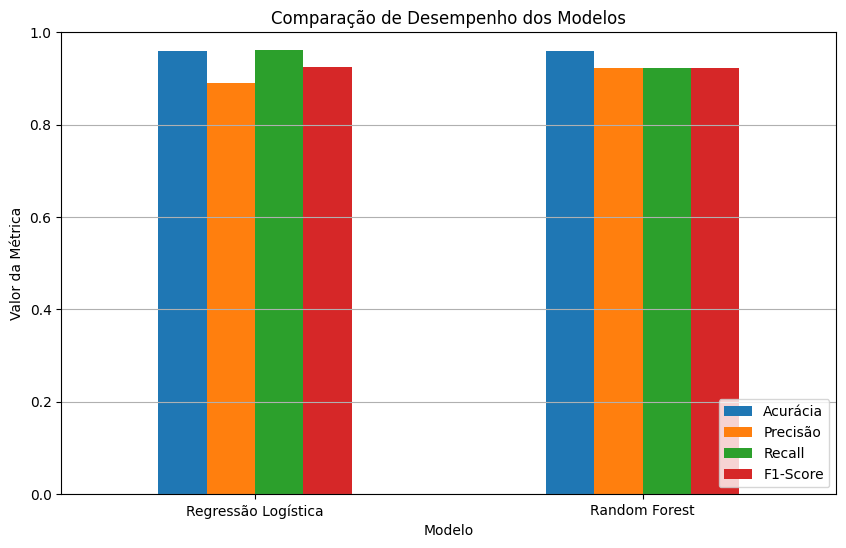

In [ ]:
# Gráfico comparativo dos modelos

resultados_grafico = resultados.set_index("Modelo")

resultados_grafico.plot(kind="bar", figsize=(10, 6))

plt.title("Comparação de Desempenho dos Modelos")
plt.xlabel("Modelo")
plt.ylabel("Valor da Métrica")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y")
plt.show()

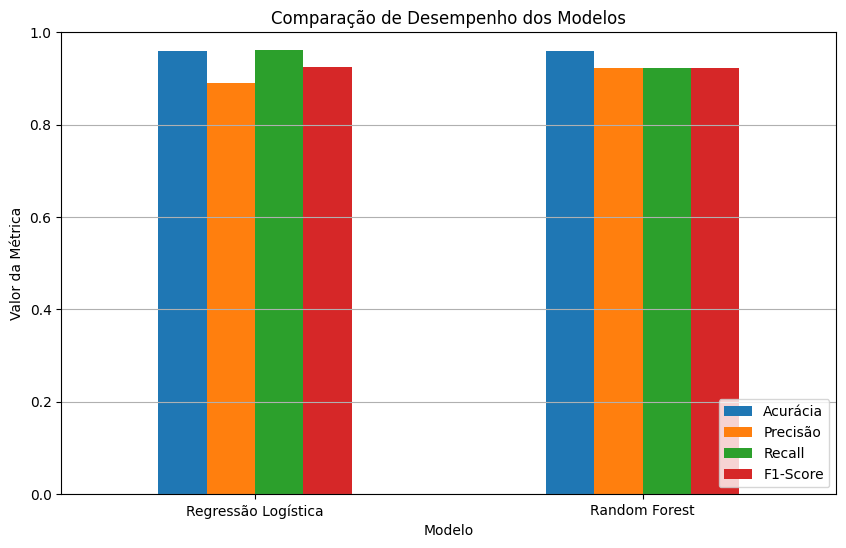

Gráfico salvo com sucesso.


In [ ]:
# Salvar o gráfico

ax = resultados_grafico.plot(kind="bar", figsize=(10, 6))

plt.title("Comparação de Desempenho dos Modelos")
plt.xlabel("Modelo")
plt.ylabel("Valor da Métrica")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y")

plt.savefig("grafico_comparacao_modelos.png", dpi=300, bbox_inches="tight")
plt.show()

print("Gráfico salvo com sucesso.")

# Conclusao



O projeto demonstrou a aplicação de modelos de Machine Learning em um problema de gestão de estoque semelhante ao encontrado em sistemas ERP. O objetivo foi prever se determinado produto precisa ou não de reposição, com base em informações como estoque atual, estoque mínimo, consumo médio mensal e prazo de reposição.

Foram treinados e comparados dois modelos: Regressão Logística e Random Forest. A avaliação foi realizada com base nas métricas acurácia, precisão, recall e F1-Score.

O modelo com melhor F1-Score pode ser considerado o mais adequado para este problema, pois essa métrica equilibra precisão e recall. No contexto de controle de estoque, esse equilíbrio é importante para reduzir tanto o risco de compras desnecessárias quanto o risco de falta de produtos.

Como melhorias futuras, sugere-se utilizar uma base real extraída de um sistema ERP, incluir variáveis como sazonalidade, histórico de compras, tempo real de entrega dos fornecedores e volume financeiro movimentado por produto.

```
# Isto está formatado como código
```

